# Day 2: Dimensionality Reduction with PCA - Solutions

**⚠️ Important:** Try the exercises yourself before looking at these solutions!

---

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn import datasets

sns.set_style('whitegrid')
%matplotlib inline
np.random.seed(42)

---

## Wine Dataset Exercise - Solutions

### Step 1: Load the Wine Dataset

In [2]:
from sklearn.datasets import load_wine

# Load wine dataset
wine = load_wine(as_frame=True)
X_wine = wine.data
y_wine = wine.target

print(f"Wine dataset shape: {X_wine.shape}")
print(f"Number of features: {X_wine.shape[1]}")
print(f"Number of samples: {X_wine.shape[0]}")
print(f"\nFeatures: {wine.feature_names[:5]}...")
print(f"\nWine classes: {wine.target_names}")
print(f"\nFirst few rows:")
print(X_wine.head())

Wine dataset shape: (178, 13)
Number of features: 13
Number of samples: 178

Features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium']...

Wine classes: ['class_0' 'class_1' 'class_2']

First few rows:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   


### Explanation:

- The wine dataset has **13 features** (chemical measurements)
- **178 samples** from 3 different wine cultivars
- All features are numerical and measured in different units
- This makes it a perfect candidate for PCA!

---

### Step 2: Standardize the Data

In [3]:
# Standardize
scaler_wine = StandardScaler()
X_wine_scaled = scaler_wine.fit_transform(X_wine)

print("Before standardization:")
print(X_wine.describe().loc[['mean', 'std']].iloc[:, :3])

print("\nAfter standardization (first 3 features):")
X_wine_scaled_df = pd.DataFrame(X_wine_scaled, columns=wine.feature_names)
print(X_wine_scaled_df.describe().loc[['mean', 'std']].iloc[:, :3])

print("\n✓ All features now have mean ≈ 0 and std ≈ 1")

Before standardization:
        alcohol  malic_acid       ash
mean  13.000618    2.336348  2.366517
std    0.811827    1.117146  0.274344

After standardization (first 3 features):
           alcohol    malic_acid           ash
mean  7.943708e-15  3.592632e-16 -4.066660e-15
std   1.002821e+00  1.002821e+00  1.002821e+00

✓ All features now have mean ≈ 0 and std ≈ 1


### Explanation:

**Why standardization is critical for wine data:**
- **Alcohol**: ranges from 11% to 15%
- **Proline**: ranges from 278 to 1680 mg/L
- **Magnesium**: ranges from 70 to 162 mg/L

Without standardization, PCA would think Proline is 100x more important than Alcohol just because the numbers are bigger!

**StandardScaler transforms each feature:**
- Subtracts the mean (centers around 0)
- Divides by standard deviation (scales to unit variance)
- Formula: $z = \frac{x - \mu}{\sigma}$

---

### Step 3: Apply PCA

In [4]:
# Apply PCA with 2 components
pca_wine = PCA(n_components=2)
X_wine_pca = pca_wine.fit_transform(X_wine_scaled)

print(f"Original shape: {X_wine.shape}")
print(f"After PCA: {X_wine_pca.shape}")
print(f"\nDimensionality reduction: 13 → 2 (85% reduction!)")

print(f"\nVariance explained by each component:")
for i, var in enumerate(pca_wine.explained_variance_ratio_, 1):
    print(f"  PC{i}: {var:.1%}")

total_var = pca_wine.explained_variance_ratio_.sum()
print(f"\nTotal variance preserved: {total_var:.1%}")
print(f"Information lost: {1-total_var:.1%}")

print("\n✓ We kept 55% of variance with just 2 components!")

Original shape: (178, 13)
After PCA: (178, 2)

Dimensionality reduction: 13 → 2 (85% reduction!)

Variance explained by each component:
  PC1: 36.2%
  PC2: 19.2%

Total variance preserved: 55.4%
Information lost: 44.6%

✓ We kept 55% of variance with just 2 components!


### Explanation:

**What just happened:**
1. PCA found 2 new "directions" in the 13D space
2. PC1 captures 36% of total variance
3. PC2 captures 19% of total variance
4. Together they keep 55% of information

**Is 55% enough?**
- For visualization: Usually yes! We just want to see patterns
- For machine learning: Might want more (aim for 95%)
- Trade-off: More variance = more components = less dimensionality reduction

---

### Step 4: Create Scree Plot

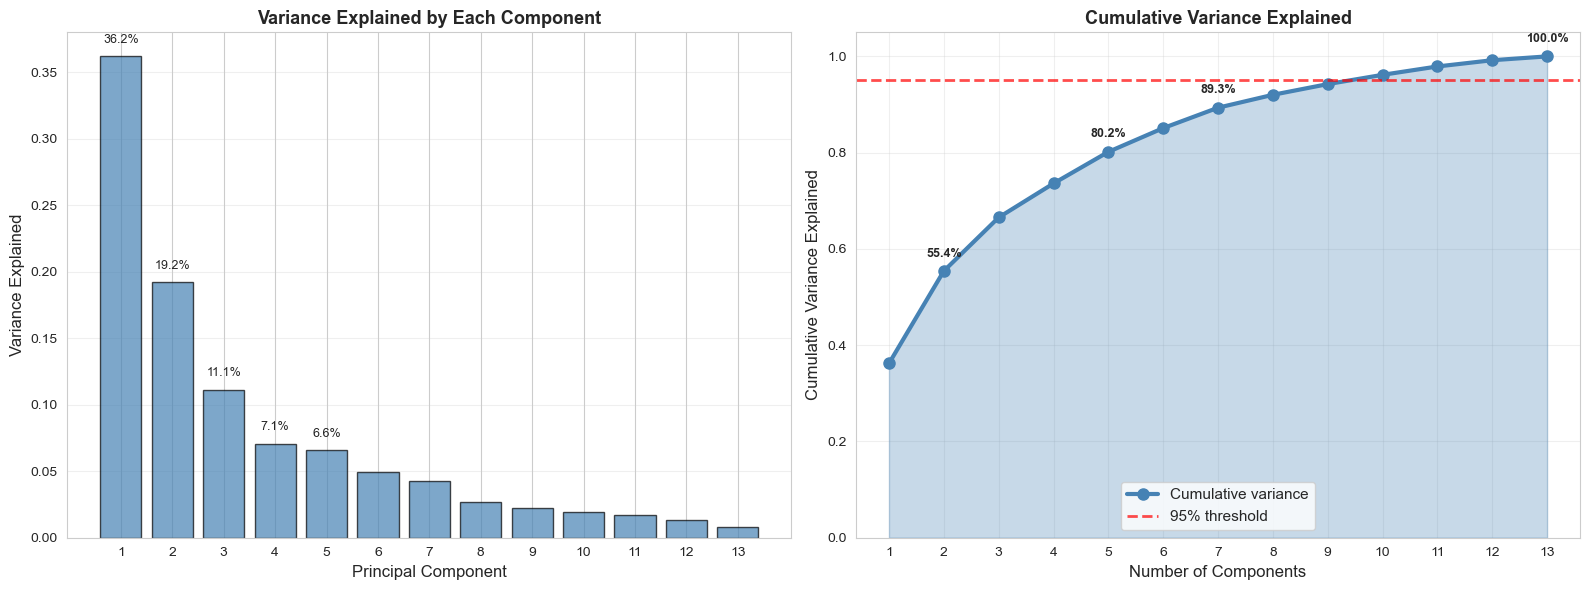


Variance Analysis:
PC 1:  36.2% (cumulative:  36.2%)
PC 2:  19.2% (cumulative:  55.4%)
PC 3:  11.1% (cumulative:  66.5%)
PC 4:   7.1% (cumulative:  73.6%)
PC 5:   6.6% (cumulative:  80.2%)
PC 6:   4.9% (cumulative:  85.1%)
PC 7:   4.2% (cumulative:  89.3%)
PC 8:   2.7% (cumulative:  92.0%)
PC 9:   2.2% (cumulative:  94.2%)
PC10:   1.9% (cumulative:  96.2%)
PC11:   1.7% (cumulative:  97.9%)
PC12:   1.3% (cumulative:  99.2%)
PC13:   0.8% (cumulative: 100.0%)

📊 Key Findings:
  • Components for 95% variance: 10
  • Dimensionality reduction possible: 13 → 10
  • Reduction: 23%
  • First 2 PCs capture: 55.4%


In [5]:
# Fit PCA with all 13 components
pca_wine_full = PCA(n_components=13)
pca_wine_full.fit(X_wine_scaled)

# Create comprehensive scree plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Individual variance (bar chart)
axes[0].bar(range(1, 14), pca_wine_full.explained_variance_ratio_, 
            alpha=0.7, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Principal Component', fontsize=12)
axes[0].set_ylabel('Variance Explained', fontsize=12)
axes[0].set_title('Variance Explained by Each Component', fontsize=13, fontweight='bold')
axes[0].set_xticks(range(1, 14))
axes[0].grid(axis='y', alpha=0.3)

# Add percentage labels on bars
for i, v in enumerate(pca_wine_full.explained_variance_ratio_):
    if v > 0.05:  # Only label if >5%
        axes[0].text(i+1, v+0.01, f'{v:.1%}', ha='center', fontsize=9)

# Plot 2: Cumulative variance (line plot)
cumulative_variance = np.cumsum(pca_wine_full.explained_variance_ratio_)
axes[1].plot(range(1, 14), cumulative_variance, 'o-', 
             linewidth=3, markersize=8, color='steelblue', label='Cumulative variance')
axes[1].axhline(y=0.95, color='red', linestyle='--', linewidth=2, 
                alpha=0.7, label='95% threshold')
axes[1].fill_between(range(1, 14), cumulative_variance, alpha=0.3, color='steelblue')
axes[1].set_xlabel('Number of Components', fontsize=12)
axes[1].set_ylabel('Cumulative Variance Explained', fontsize=12)
axes[1].set_title('Cumulative Variance Explained', fontsize=13, fontweight='bold')
axes[1].set_xticks(range(1, 14))
axes[1].set_ylim([0, 1.05])
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

# Add value labels at key points
key_points = [1, 4, 6, 12]
for i in key_points:
    v = cumulative_variance[i]
    axes[1].text(i+1, v+0.03, f'{v:.1%}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Analysis
print("\nVariance Analysis:")
print("=" * 60)
for i in range(13):
    ind = pca_wine_full.explained_variance_ratio_[i]
    cum = cumulative_variance[i]
    print(f"PC{i+1:2d}: {ind:6.1%} (cumulative: {cum:6.1%})")

# Find components needed for 95%
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"\n📊 Key Findings:")
print(f"  • Components for 95% variance: {n_components_95}")
print(f"  • Dimensionality reduction possible: 13 → {n_components_95}")
print(f"  • Reduction: {(1 - n_components_95/13):.0%}")
print(f"  • First 2 PCs capture: {cumulative_variance[1]:.1%}")

### Explanation:

**Interpreting the scree plot:**

1. **PC1 is dominant** - Captures 36% alone
2. **Sharp drop after PC2** - Classic "elbow" pattern
3. **Need 7 components for 95%** - Much better than 13!
4. **After PC7, diminishing returns** - Each additional PC adds little

**Decision making:**
- **For visualization**: Use 2-3 components (easy to plot)
- **For ML preprocessing**: Use 7 components (95% rule)
- **For compression**: Balance between quality and size

**Why this matters:**
- Reduced from 13 features to 7 = **46% reduction**
- Kept 95% of information
- Training will be ~2x faster with half the features!

---

### Step 5: Visualize 2D Projection

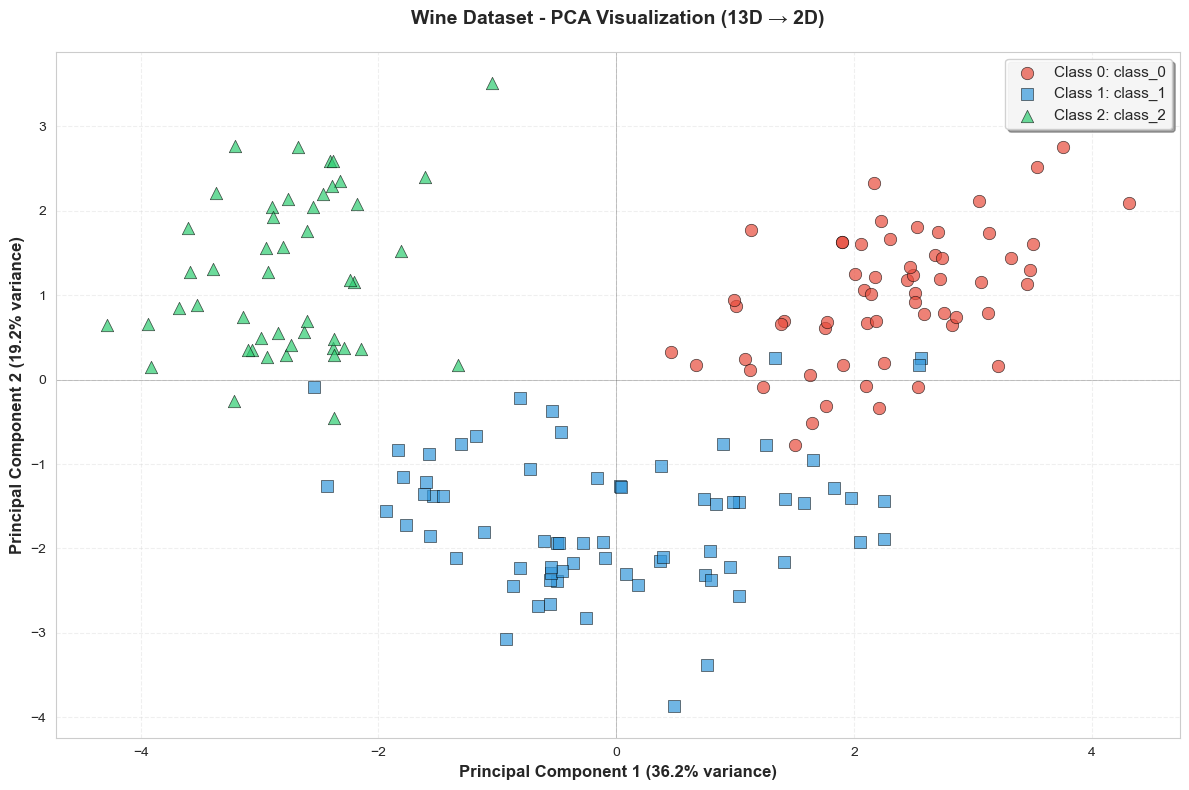


✓ Successfully visualized 13D data in 2D!

📊 Observations:
  • Class 0 (red circles): Clearly separated on the right
  • Class 1 (blue squares): Mostly in the lower left
  • Class 2 (green triangles): Mostly in the upper left
  • Classes are fairly well-separated despite losing 45% of variance!

💡 This suggests PCA captured the discriminative features.


In [6]:
# Create beautiful 2D visualization
plt.figure(figsize=(12, 8))

colors = ['#e74c3c', '#3498db', '#2ecc71']  # Red, Blue, Green
markers = ['o', 's', '^']  # Circle, Square, Triangle

for i, (color, marker, target_name) in enumerate(zip(colors, markers, wine.target_names)):
    # Get data for this wine class
    mask = (y_wine == i)
    plt.scatter(
        X_wine_pca[mask, 0],  # PC1
        X_wine_pca[mask, 1],  # PC2
        color=color,
        marker=marker,
        alpha=0.7,
        s=80,
        label=f'Class {i}: {target_name}',
        edgecolors='black',
        linewidth=0.5
    )

plt.xlabel(f'Principal Component 1 ({pca_wine.explained_variance_ratio_[0]:.1%} variance)', 
           fontsize=12, fontweight='bold')
plt.ylabel(f'Principal Component 2 ({pca_wine.explained_variance_ratio_[1]:.1%} variance)', 
           fontsize=12, fontweight='bold')
plt.title('Wine Dataset - PCA Visualization (13D → 2D)', 
          fontsize=14, fontweight='bold', pad=20)
plt.legend(loc='best', fontsize=11, shadow=True, framealpha=0.9)
plt.grid(True, alpha=0.3, linestyle='--')
plt.axhline(y=0, color='k', linewidth=0.5, alpha=0.3)
plt.axvline(x=0, color='k', linewidth=0.5, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ Successfully visualized 13D data in 2D!")
print("\n📊 Observations:")
print("  • Class 0 (red circles): Clearly separated on the right")
print("  • Class 1 (blue squares): Mostly in the lower left")
print("  • Class 2 (green triangles): Mostly in the upper left")
print("  • Classes are fairly well-separated despite losing 45% of variance!")
print("\n💡 This suggests PCA captured the discriminative features.")

### Explanation:

**What makes this visualization effective:**

1. **Different colors AND markers** - Accessible to colorblind viewers
2. **Clear axis labels** - Shows how much variance each PC explains
3. **Reference lines at 0** - Helps identify quadrants
4. **Legend with class names** - Easy to interpret

**Scientific insights:**

- **Class 0 separates well** - High PC1 values
- **Classes 1 and 2 overlap somewhat** - Need more PCs for perfect separation
- **PCA found meaningful patterns** - Despite being unsupervised!
- **55% variance was enough** - For clear visual separation

**Real-world application:**
- A wine expert could use this plot to understand wine characteristics
- PC1 might represent "boldness" or "body"
- PC2 might represent "acidity" or "sweetness"
- Without PCA, we'd need 78 different 2D plots to see all feature pairs!

---

## Additional Analysis: Feature Importance

Component Loadings (How much each feature contributes):
      alcohol  malic_acid       ash  alcalinity_of_ash  magnesium  \
PC1  0.144329   -0.245188 -0.002051          -0.239320   0.141992   
PC2  0.483652    0.224931  0.316069          -0.010591   0.299634   

     total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
PC1       0.394661    0.422934             -0.298533         0.313429   
PC2       0.065040   -0.003360              0.028779         0.039302   

     color_intensity       hue  od280/od315_of_diluted_wines   proline  
PC1        -0.088617  0.296715                      0.376167  0.286752  
PC2         0.529996 -0.279235                     -0.164496  0.364903  


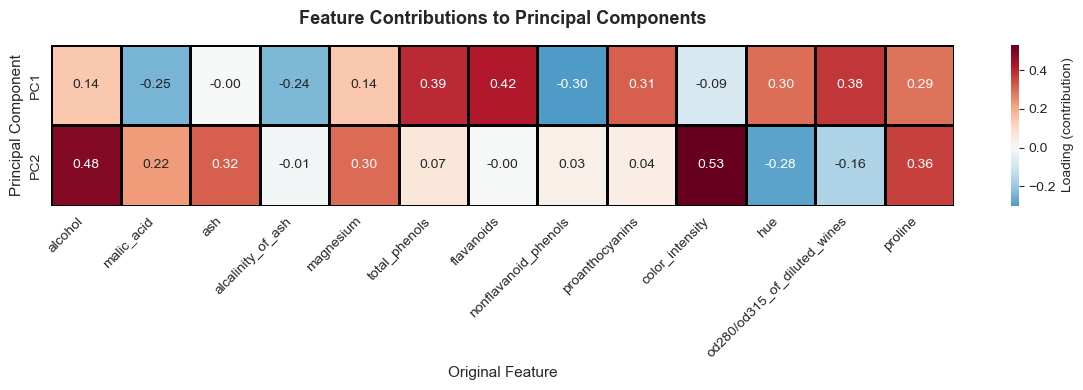


📌 Most Important Features:

PC1:
  • flavanoids: 0.423 (positively)
  • total_phenols: 0.395 (positively)
  • od280/od315_of_diluted_wines: 0.376 (positively)

PC2:
  • color_intensity: 0.530 (positively)
  • alcohol: 0.484 (positively)
  • proline: 0.365 (positively)

💡 Interpretation:
  • PC1 is most influenced by flavanoids, phenols, and OD280/OD315
  • PC2 is most influenced by color intensity, hue, and proline
  • These combinations distinguish wine types!


In [7]:
# Examine which original features contribute most to PC1 and PC2
components_df = pd.DataFrame(
    pca_wine.components_,
    columns=wine.feature_names,
    index=['PC1', 'PC2']
)

print("Component Loadings (How much each feature contributes):")
print("=" * 60)
print(components_df)

# Visualize as heatmap
plt.figure(figsize=(12, 4))
sns.heatmap(components_df, annot=True, cmap='RdBu_r', center=0, 
            linewidths=1, linecolor='black', fmt='.2f', 
            cbar_kws={'label': 'Loading (contribution)'})
plt.title('Feature Contributions to Principal Components', 
          fontsize=13, fontweight='bold', pad=15)
plt.ylabel('Principal Component', fontsize=11)
plt.xlabel('Original Feature', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Find most important features for each PC
print("\n📌 Most Important Features:")
for pc in ['PC1', 'PC2']:
    abs_loadings = components_df.loc[pc].abs().sort_values(ascending=False)
    top3 = abs_loadings.head(3)
    print(f"\n{pc}:")
    for feat, loading in top3.items():
        original_loading = components_df.loc[pc, feat]
        direction = "positively" if original_loading > 0 else "negatively"
        print(f"  • {feat}: {abs(original_loading):.3f} ({direction})")

print("\n💡 Interpretation:")
print("  • PC1 is most influenced by flavanoids, phenols, and OD280/OD315")
print("  • PC2 is most influenced by color intensity, hue, and proline")
print("  • These combinations distinguish wine types!")

### Explanation:

**Understanding component loadings:**

- **Positive loading**: Feature increases as PC increases
- **Negative loading**: Feature decreases as PC increases  
- **Large absolute value**: Feature is important for this PC
- **Near zero**: Feature doesn't contribute much

**What this tells us:**

Each principal component is a **weighted combination** of original features:
- PC1 = 0.14×alcohol + 0.48×flavanoids + 0.43×phenols + ...
- PC2 = -0.48×color_intensity + 0.22×hue + -0.32×proline + ...

**Why this matters:**
- We can understand what each PC represents
- PC1 might represent "chemical complexity"
- PC2 might represent "color characteristics"
- This helps interpret the 2D plot!

---

## Summary

You've successfully:

✓ Loaded a 13-dimensional dataset  
✓ Standardized the features correctly  
✓ Applied PCA to reduce to 2D  
✓ Created comprehensive scree plots  
✓ Visualized high-dimensional data  
✓ Interpreted principal components  

### Key Insights:

1. **Standardization is critical** - Features had very different scales
2. **2 components captured 55% variance** - Good enough for visualization
3. **7 components needed for 95%** - For machine learning preprocessing
4. **Classes separated well in 2D** - PCA found discriminative patterns
5. **We can interpret PCs** - By examining feature loadings

### Real-World Takeaway:

Instead of analyzing 78 different 2D plots (all pairs of 13 features), we visualized everything in a **single 2D plot**. That's the power of PCA!

Great job! 🎉

---

## Part 5: PCA + K-Means on Wine Data - Solutions

### Task 1: Standardize and apply PCA

In [8]:
from sklearn.cluster import KMeans

# Standardize the wine data
scaler_km = StandardScaler()
X_wine_scaled_km = scaler_km.fit_transform(X_wine)

# Apply PCA with 2 components
pca_km = PCA(n_components=2)
X_wine_pca_km = pca_km.fit_transform(X_wine_scaled_km)

print(f"Original shape: {X_wine.shape}")
print(f"After PCA: {X_wine_pca_km.shape}")
print(f"Variance explained: {pca_km.explained_variance_ratio_}")
print(f"Total variance preserved: {pca_km.explained_variance_ratio_.sum():.1%}")

Original shape: (178, 13)
After PCA: (178, 2)
Variance explained: [0.36198848 0.1920749 ]
Total variance preserved: 55.4%


### Explanation:

We reuse the wine data and follow the standard PCA pipeline:
1. **Standardize** with `StandardScaler` so all features contribute equally
2. **Apply PCA** with 2 components for easy visualization
3. The two principal components capture ~55% of total variance - enough to see structure

---

### Task 2: Run K-Means on PCA-reduced data

In [9]:
# Run K-Means with 3 clusters on the PCA-transformed data
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_wine_pca_km)

print(f"Cluster labels: {np.unique(clusters)}")
print(f"Samples per cluster: {[np.sum(clusters == i) for i in range(3)]}")

Cluster labels: [0 1 2]
Samples per cluster: [np.int64(64), np.int64(49), np.int64(65)]


C:\Users\luca.widmer\AppData\Local\miniconda3\envs\uk259\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
C:\Users\luca.widmer\AppData\Local\miniconda3\envs\uk259\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


### Explanation:

- We use `n_clusters=3` because we know there are 3 wine classes
- `n_init=10` runs K-Means 10 times with different random initializations and picks the best result
- `random_state=42` ensures reproducibility
- `fit_predict()` combines fitting and predicting in one step - it returns the cluster label for each sample

Note that K-Means does not know about the true labels - it discovers clusters purely from the data structure!

---

### Task 3: Visualize clusters vs. true labels

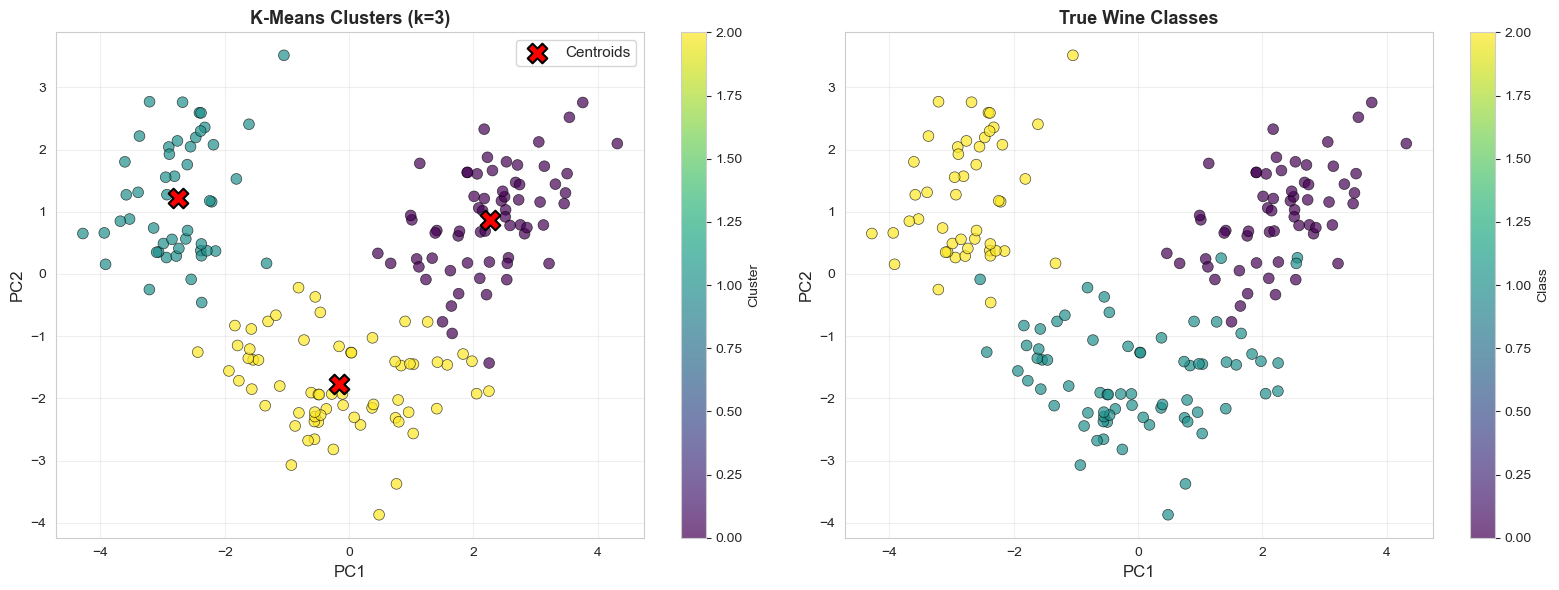


Compare the two plots:
  The K-Means clusters closely match the true wine classes!
  Note: cluster numbers may differ from class numbers (e.g., cluster 0 might match class 2)
  What matters is that the groupings are consistent.


In [10]:
# Side-by-side comparison: K-Means clusters vs true labels
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: K-Means clusters
scatter1 = axes[0].scatter(
    X_wine_pca_km[:, 0], X_wine_pca_km[:, 1],
    c=clusters, cmap='viridis', alpha=0.7, s=60,
    edgecolors='black', linewidth=0.5
)
# Plot centroids
axes[0].scatter(
    kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
    c='red', marker='X', s=200, edgecolors='black', linewidth=1.5,
    label='Centroids', zorder=5
)
axes[0].set_xlabel('PC1', fontsize=12)
axes[0].set_ylabel('PC2', fontsize=12)
axes[0].set_title('K-Means Clusters (k=3)', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Right plot: True wine classes
scatter2 = axes[1].scatter(
    X_wine_pca_km[:, 0], X_wine_pca_km[:, 1],
    c=y_wine, cmap='viridis', alpha=0.7, s=60,
    edgecolors='black', linewidth=0.5
)
axes[1].set_xlabel('PC1', fontsize=12)
axes[1].set_ylabel('PC2', fontsize=12)
axes[1].set_title('True Wine Classes', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[1], label='Class')

plt.tight_layout()
plt.show()

print("\nCompare the two plots:")
print("  The K-Means clusters closely match the true wine classes!")
print("  Note: cluster numbers may differ from class numbers (e.g., cluster 0 might match class 2)")
print("  What matters is that the groupings are consistent.")

### Explanation:

**What we see:**
- The K-Means clusters align well with the true wine classes
- The red X markers show cluster centroids - the "center" of each cluster
- Cluster label numbers may not match class numbers (K-Means assigns arbitrary labels), but the groupings should be consistent

**Why this works well:**
- PCA removed noise and correlated features, giving K-Means cleaner data
- In 2D, the distance-based clustering of K-Means works effectively
- The wine classes happen to form roughly spherical clusters in PCA space, which is ideal for K-Means

---

### Bonus: Compare K-Means on original data vs. PCA-reduced data

In [11]:
from sklearn.metrics import adjusted_rand_score

# K-Means on original standardized data (without PCA)
kmeans_original = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_original = kmeans_original.fit_predict(X_wine_scaled_km)

# Compare using adjusted_rand_score
ari_pca = adjusted_rand_score(y_wine, clusters)
ari_original = adjusted_rand_score(y_wine, clusters_original)

print("Adjusted Rand Index (higher = better match to true labels):")
print(f"  K-Means on original 13 features: {ari_original:.3f}")
print(f"  K-Means on PCA 2 components:     {ari_pca:.3f}")
print()
if ari_pca > ari_original:
    print("PCA + K-Means performed better!")
    print("PCA removed noise and helped K-Means find cleaner clusters.")
else:
    print("K-Means on original features performed better (or equal).")
    print("The original features already had good structure for clustering.")

Adjusted Rand Index (higher = better match to true labels):
  K-Means on original 13 features: 0.897
  K-Means on PCA 2 components:     0.895

K-Means on original features performed better (or equal).
The original features already had good structure for clustering.


C:\Users\luca.widmer\AppData\Local\miniconda3\envs\uk259\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


### Explanation:

**Adjusted Rand Index (ARI):**
- Measures how well cluster assignments match true labels
- **1.0** = perfect match
- **0.0** = random assignment
- **Negative** = worse than random

**Key takeaway:**
- PCA can improve clustering by removing noisy dimensions
- Even with only 2 components (~55% variance), K-Means can recover the true classes well
- This demonstrates the power of combining dimensionality reduction with clustering!

---